Adds L1 penalty to linear regression, which can shrink some coefficients exactly to zero.

Useful for feature selection and building sparse, interpretable models.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[28.28653456]
-2.0437417204965924


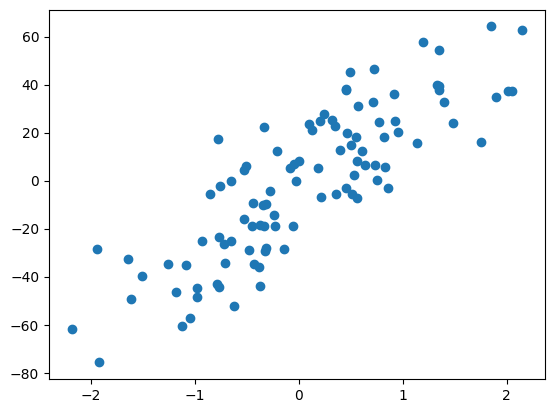

In [13]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

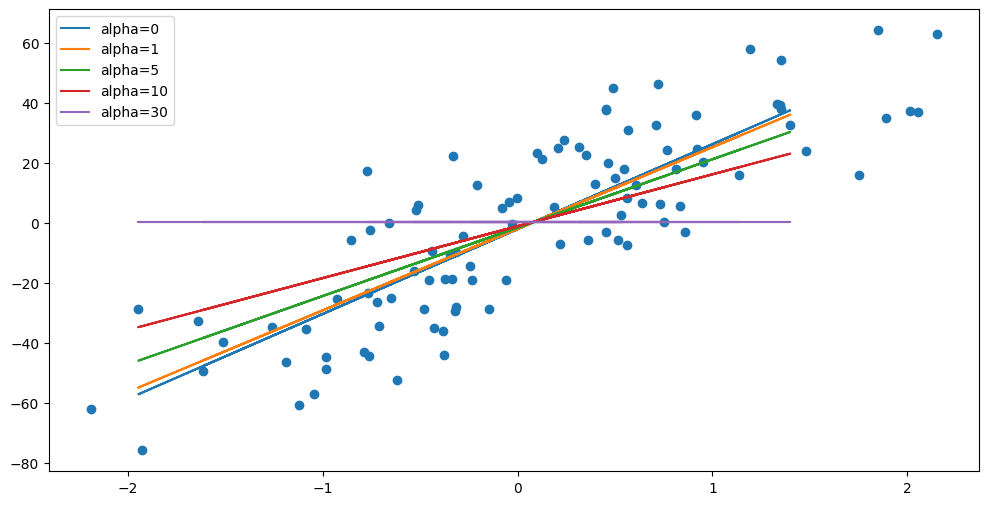

In [14]:
alphas = [0, 1, 5, 10, 30]
plt.figure(figsize=(12, 6))
plt.scatter(X, y)

for i in alphas:
    if i == 0:
        # alpha=0 means no regularization, so Lasso becomes simple Linear Regression
        # Using LinearRegression directly is the correct and efficient way
        from sklearn.linear_model import LinearRegression
        L = LinearRegression()
    else:
        # For alpha > 0, Lasso works fine
        # max_iter=10000 gives the model enough iterations to converge
        L = Lasso(alpha=i, max_iter=10000)
    
    L.fit(X_train, y_train)
    plt.plot(X_test, L.predict(X_test), label='alpha={}'.format(i))

plt.legend()
plt.show()

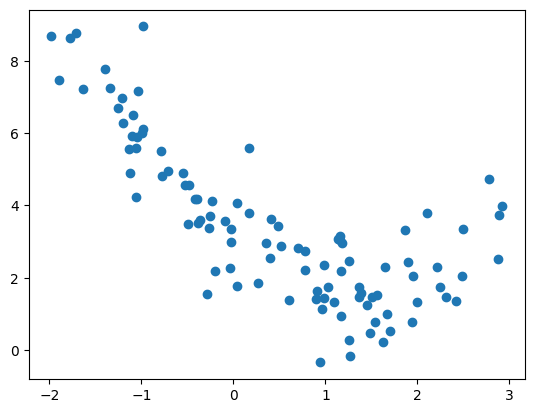

In [15]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

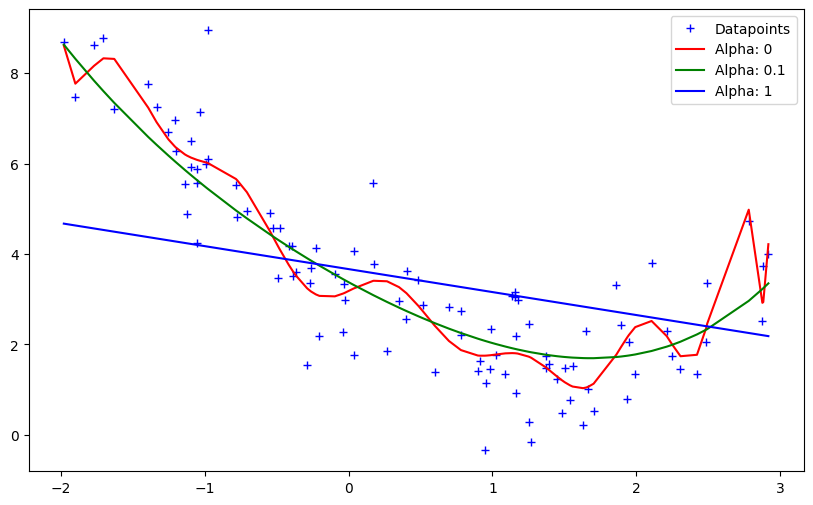

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso, LinearRegression

def get_preds_lasso(x1, x2, alpha):
    if alpha == 0:
        model = Pipeline([
            ('poly_feats', PolynomialFeatures(degree=16)),
            # StandardScaler not needed for LinearRegression, but kept for consistency
            ('scaler', StandardScaler()),
            ('linear', LinearRegression())
        ])
    else:
        model = Pipeline([
            ('poly_feats', PolynomialFeatures(degree=16)),
            # StandardScaler normalizes all features to same scale (mean=0, std=1)
            # degree=16 creates features like x^16 which are huge numbers
            # without scaling, Lasso struggles to converge
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=10000))
        ])
    
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()